In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Analysis dataset

The data used for this project come from: https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis

In [2]:
dataset = pd.read_csv("dataset.csv")

**1.1 Understanding the dataset**

In [3]:
dataset.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


The dataset contains 19 features and one label (exam_score). Since the exam score consists of continuous numerical values, this is a regression problem. There are 6 numerical features and 13 categorical features.

The 6 numerical features can be divided into 4 continuous features (Hours_Studied, Attendance, Sleep_Hours, Previous_Scores) and 2 discrete features (Tutoring_Sessions, Physical_Activity).

The 13 categorical features can be further divided as follows:
- Ordinal features (8): Parental_Involvement, Access_to_Resources, Motivation_Level, Family_Income, Teacher_Quality, Peer_Influence, Parental_Education_Level, Distance_from_Home
- Nominal feature (1): School_Type
- Binary features (4): Extracurricular_Activities, Internet_Access, Learning_Disabilities, Gender

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

The dataset contains 6,607 entries. All feature types are correct, so no type handling is needed during preprocessing. However, there are missing values in Teacher_Quality, Parental_Education_Level, and Distance_from_Home, which need to be properly handled.

In [5]:
dataset.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
dataset.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

**1.2 Data Visualization**

**1.2.1 Lable - Exam Score**

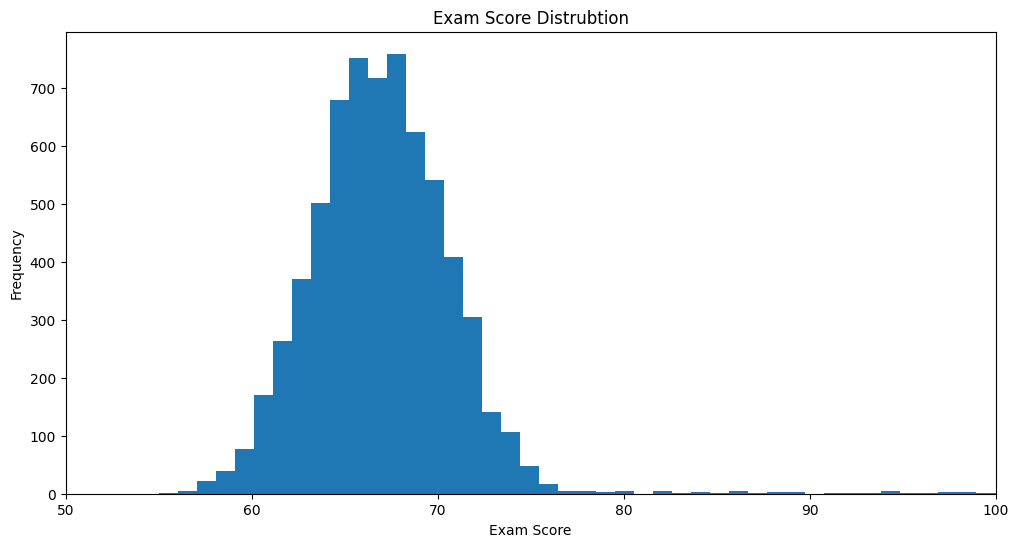

In [7]:
plt.figure(figsize=(12, 6))
plt.hist(dataset["Exam_Score"], bins=45)
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.title("Exam Score Distrubtion")
plt.xlim(50, 100)
plt.show()

The target variable (exam score) follows an approximately normal (Gaussian) distribution. Observed values range from 55 to 101, although the valid score range is expected to be 0–100. The value of 101 is therefore likely a data error or outlier and should be addressed during preprocessing.

Most observations are concentrated in the range of 60 to 75, with a peak around 68 (frequency exceeding 700). Values outside this interval are relatively rare, indicating low variance in the tails and a strong central tendency.

The distribution is unimodal and fairly symmetric, making it suitable for regression-based modeling approaches that assume normally distributed residuals.

**1.2.2 - Features**

**1.2.3 - Analysis of Hours Studied column**

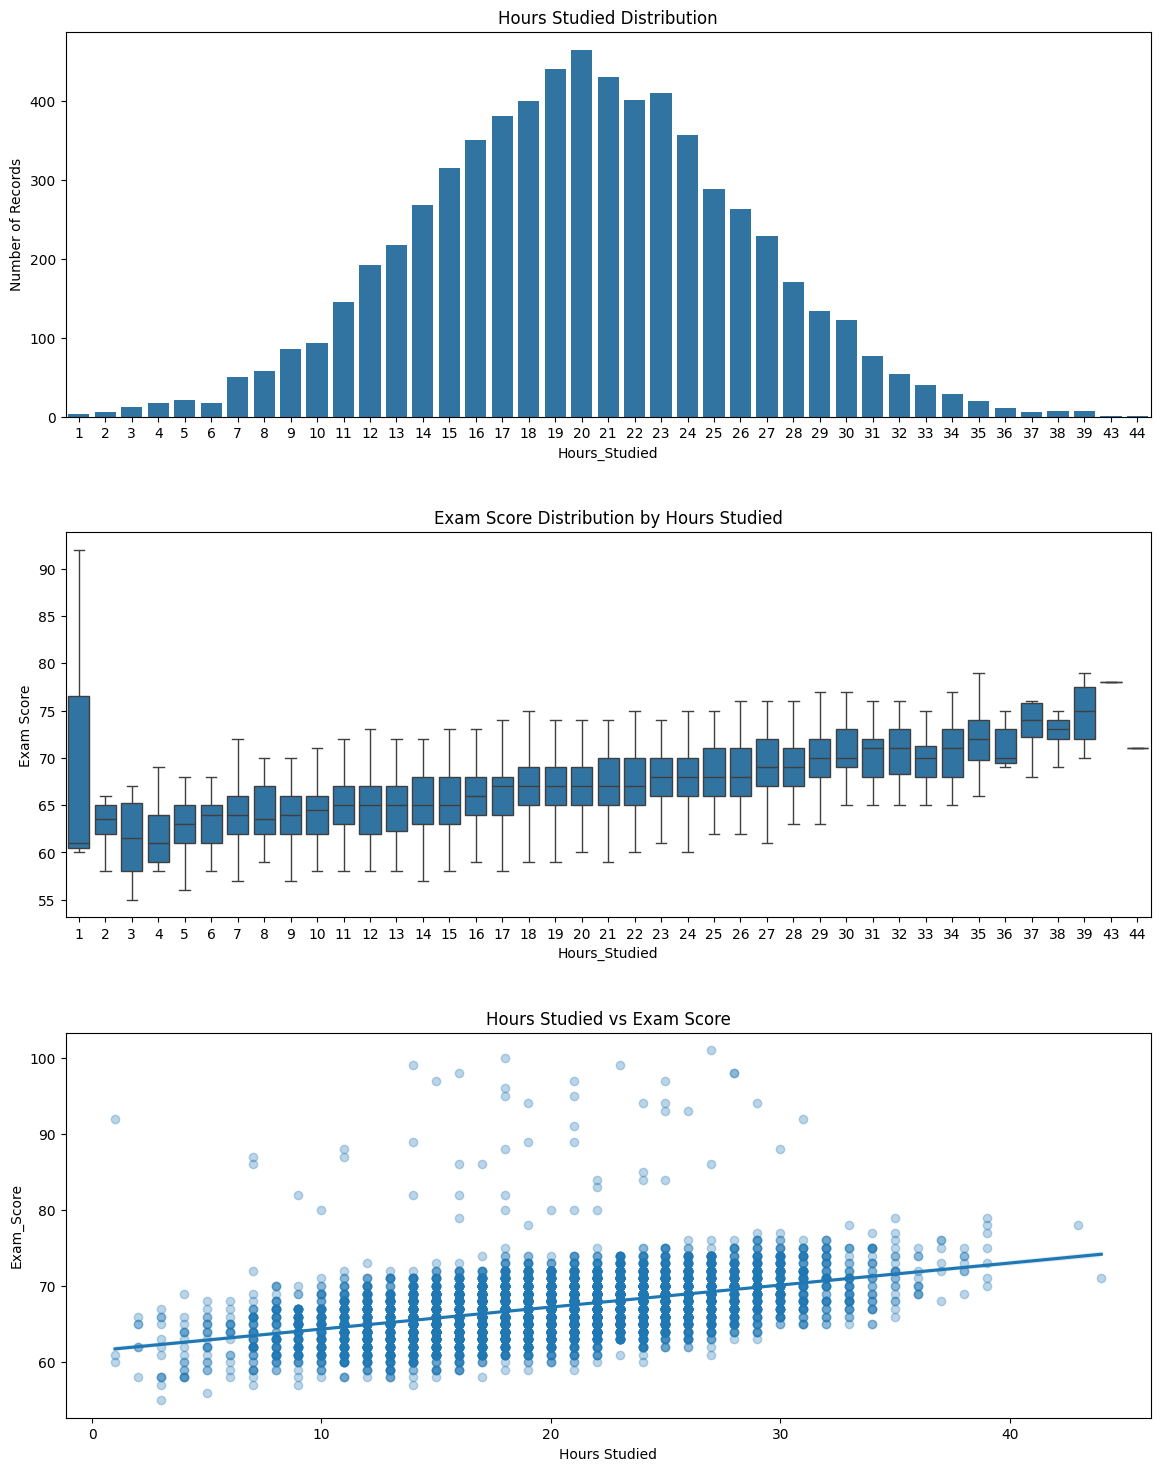

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(14, 18))
ax = ax.flatten()

sns.countplot(x="Hours_Studied", data=dataset, ax=ax[0])
ax[0].set_title("Hours Studied Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Hours_Studied", y="Exam_Score", data=dataset,
            ax=ax[1], showfliers=False)
ax[1].set_title("Exam Score Distribution by Hours Studied")
ax[1].set_ylabel("Exam Score")

sns.regplot(
    x="Hours_Studied",
    y="Exam_Score",
    data=dataset,
    ax=ax[2],
    scatter_kws={"alpha": 0.3}
)
ax[2].set_title("Hours Studied vs Exam Score")
ax[2].set_xlabel("Hours Studied")


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The distribution of the Hours_Studied variable appears to be approximately normal, as the frequency of values resembles a bell-shaped curve.

When comparing Hours_Studied with exam scores, a clear positive relationship can be observed: as the number of hours studied increases, exam scores tend to increase as well. This suggests that study time is an important predictor of performance.

However, it is important to consider the presence of outliers, as they may distort the overall correlation and lead to misleading conclusions.

**1.2.4 - Analysis of Attendance column**

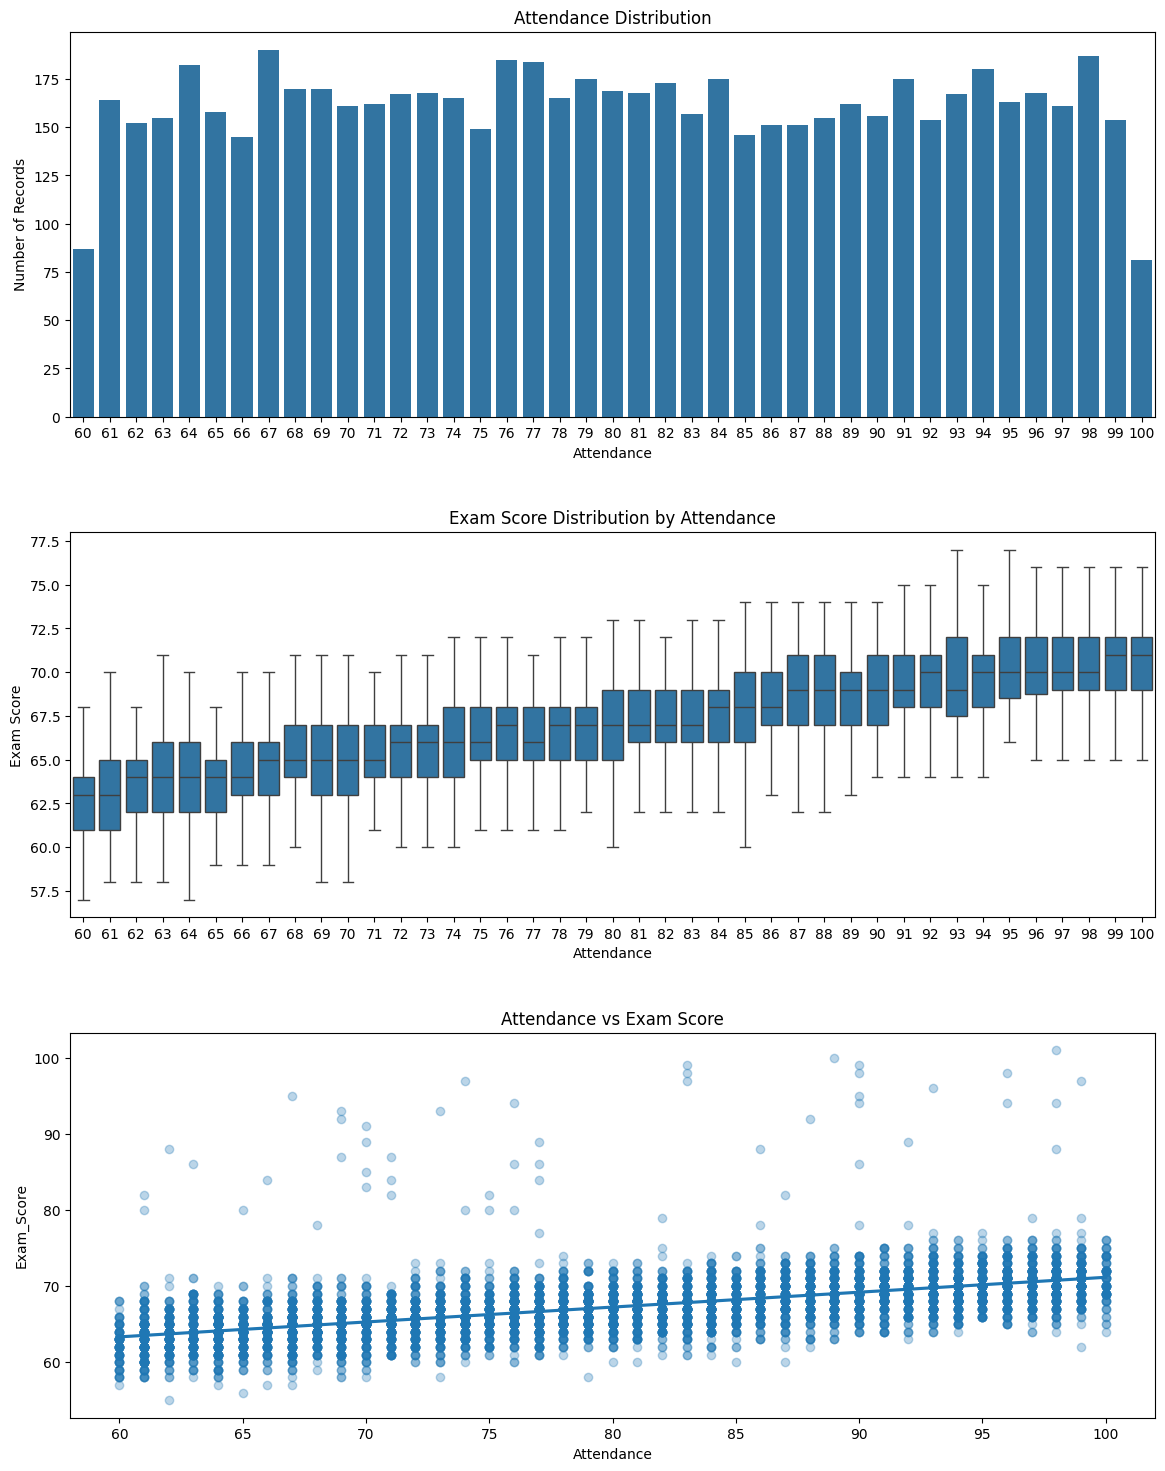

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(14, 18))
ax = ax.flatten()

sns.countplot(x="Attendance", data=dataset, ax=ax[0])
ax[0].set_title("Attendance Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Attendance", y="Exam_Score", data=dataset,
            ax=ax[1], showfliers=False)
ax[1].set_title("Exam Score Distribution by Attendance")
ax[1].set_ylabel("Exam Score")

sns.regplot(
    x="Attendance",
    y="Exam_Score",
    data=dataset,
    ax=ax[2],
    scatter_kws={"alpha": 0.3}
)
ax[2].set_title("Attendance vs Exam Score")
ax[2].set_xlabel("Attendance")


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show() 

After analyzing the attendance column, we can conclude that the distribution of attendance values is relatively stable (though not perfectly uniform), with minimum and maximum values covering roughly half of the records.

When comparing attendance with the exam score (label), we observe a pattern similar to the “hours studied” feature: higher attendance is generally associated with higher exam scores. This suggests a clear positive correlation between attendance and performance.

However, there are some outliers present in the dataset, which may distort the model’s predictions and should be taken into account during further analysis

**1.2.5 - Analysis of Parental Involvement column**

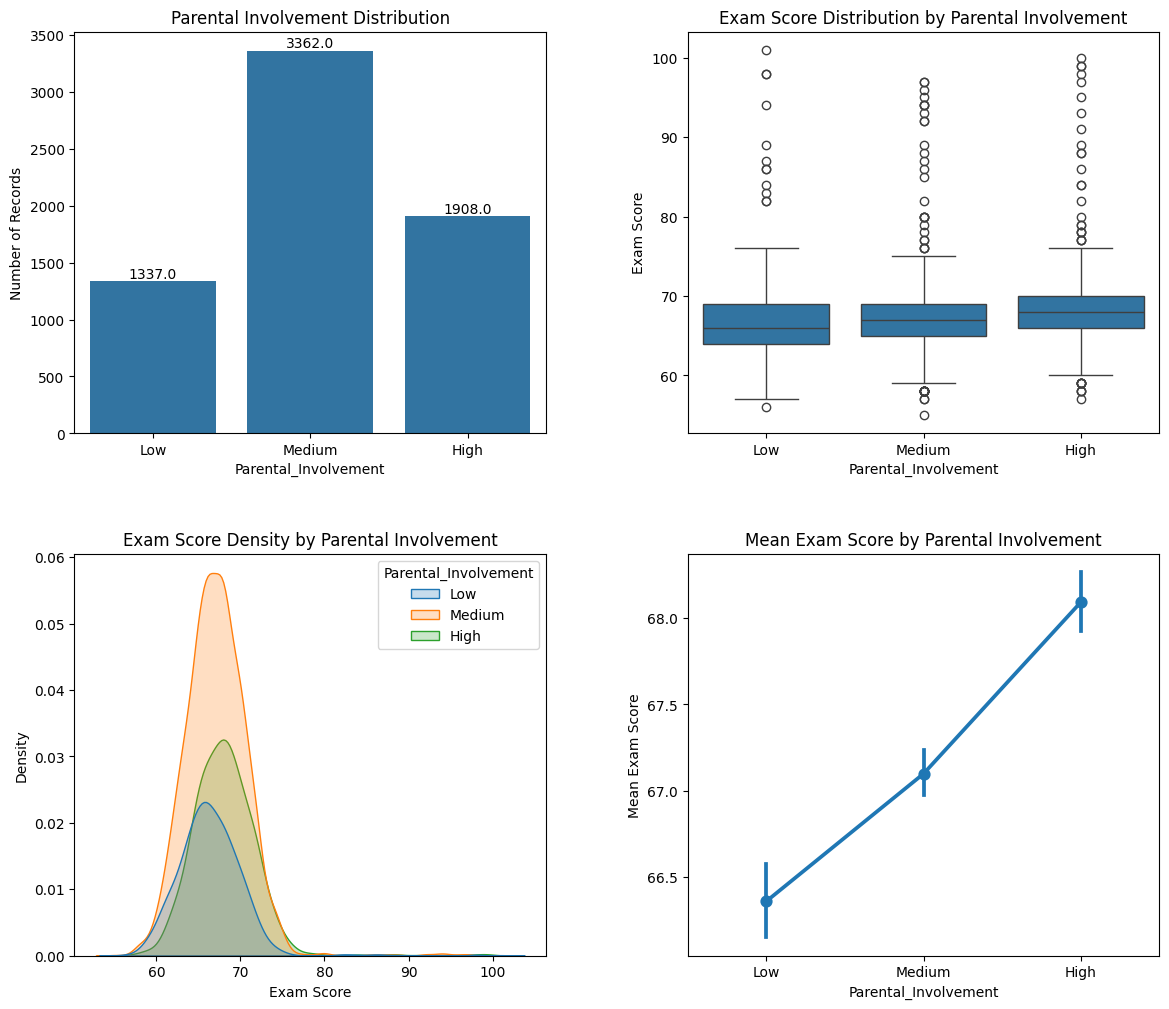

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Parental_Involvement", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Parental Involvement Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Parental_Involvement", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Parental Involvement")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Parental_Involvement", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Parental Involvement")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Parental_Involvement", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Parental Involvement")
ax[3].set_ylabel("Mean Exam Score")


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The parental involvement feature consists of three categories: low, medium, and high. The number of records is unevenly distributed across these groups, with 1,337 for low, 1,908 for medium, and 3,362 for high involvement.

When comparing the mean exam scores across these categories, the differences are relatively small, ranging from 66.5 (low) to 68 (high). Although the variation in mean scores is slight, there is still a noticeable trend indicating a positive correlation between parental involvement and exam performance.

**1.2.6 - Analysis of Access to Resources column**

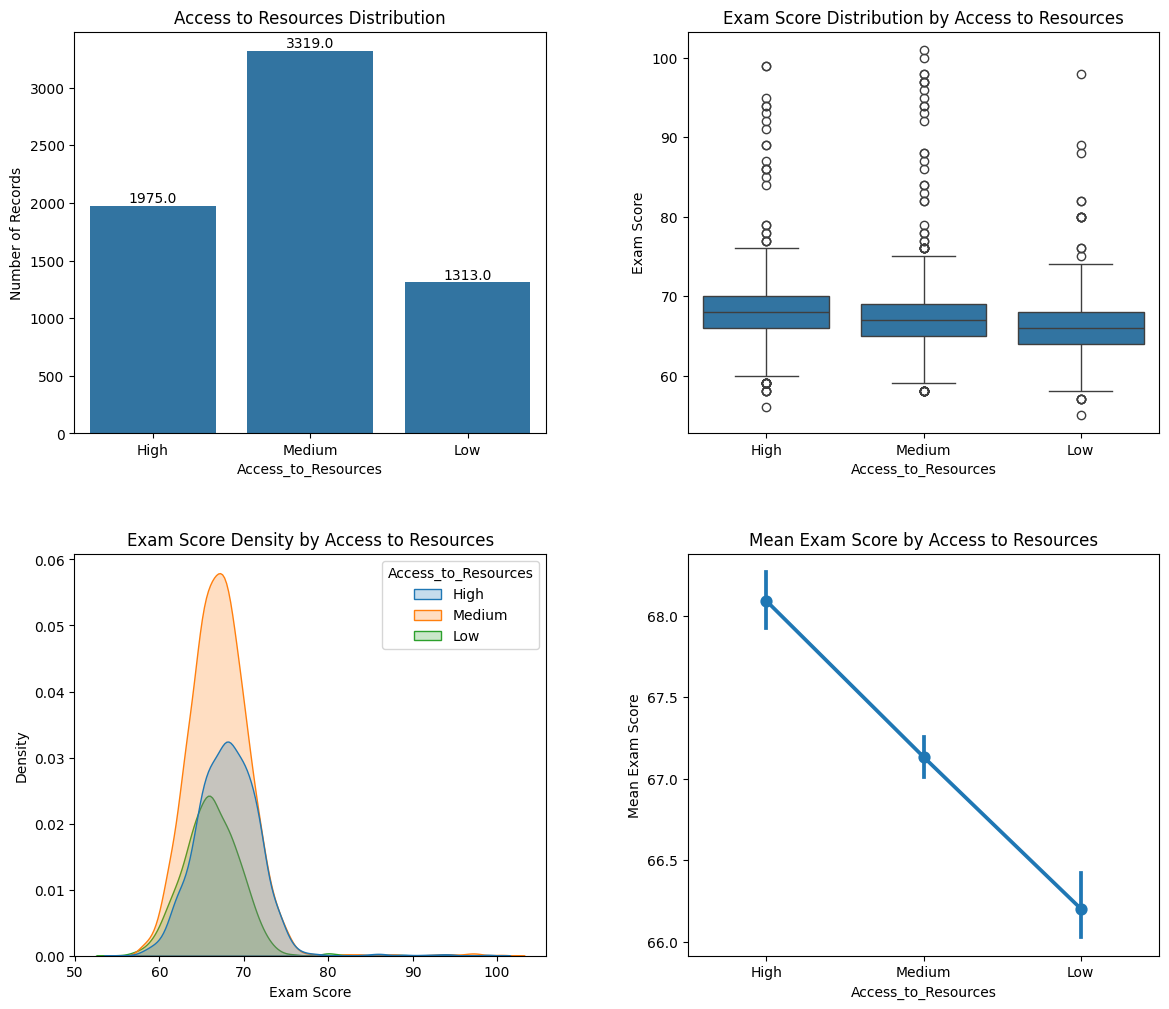

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Access_to_Resources", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Access to Resources Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Access_to_Resources", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Access to Resources")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Access_to_Resources", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Access to Resources")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Access_to_Resources", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Access to Resources")
ax[3].set_ylabel("Mean Exam Score") 


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

Access to resources is categorized into three levels: low, medium, and high. The distribution is moderately imbalanced, with 1,313 records for low access, 3,319 for medium access, and 1,975 for high access, making the medium category the most represented. Despite this imbalance, a clear positive relationship can be observed between the level of resource access and the mean exam score. Students with low access have an average score of 66.2, which increases to 67.2 for medium access, and exceeds 68 for those with high access. This trend suggests that greater access to resources is associated with improved academic performance.

**1.2.7 - Analysis of Extracurricular Activities column**

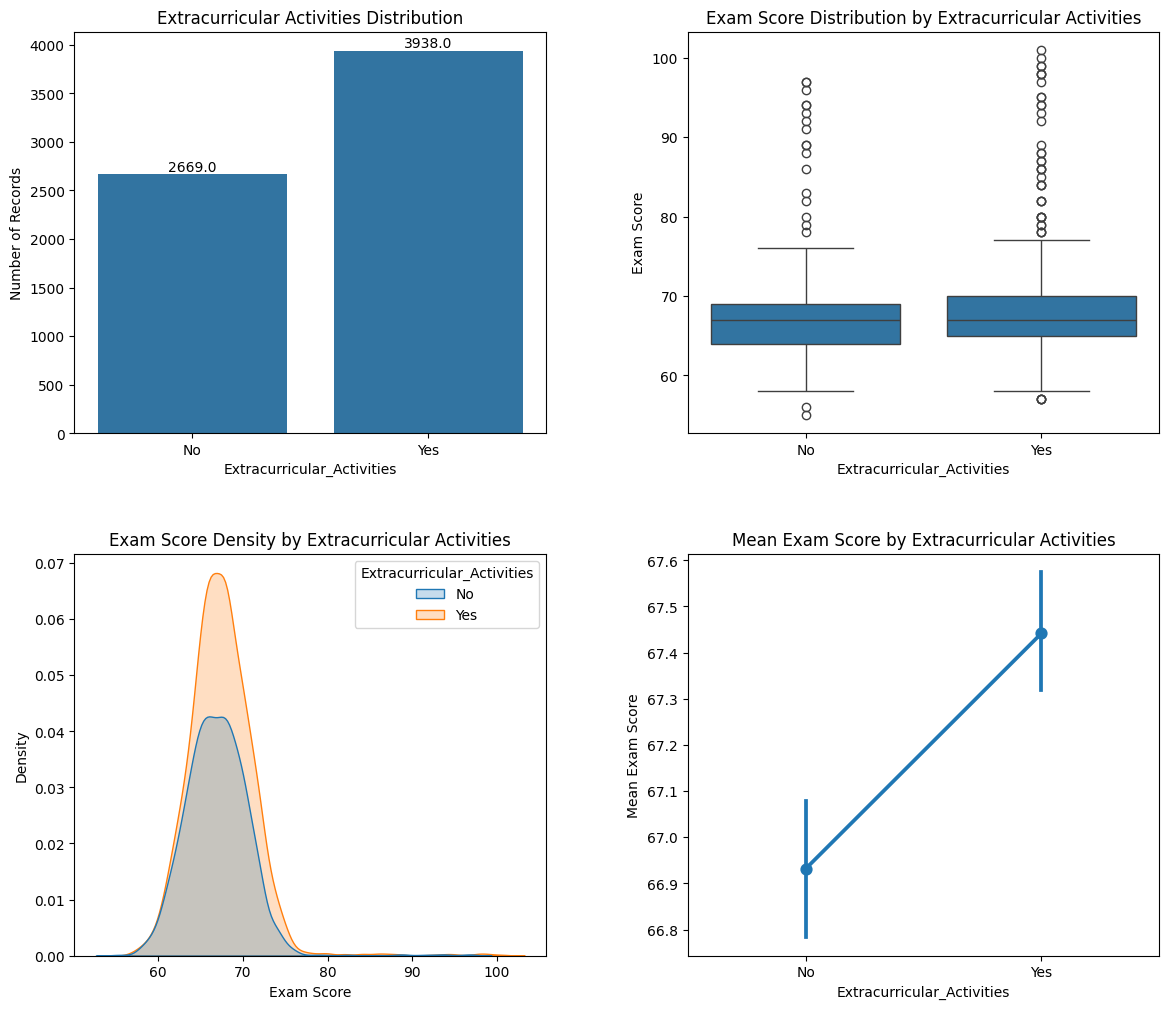

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Extracurricular_Activities", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Extracurricular Activities Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Extracurricular_Activities", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Extracurricular Activities")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Extracurricular_Activities", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Extracurricular Activities")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Extracurricular_Activities", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Extracurricular Activities")
ax[3].set_ylabel("Mean Exam Score") 


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

Extracurricular activities are represented as a binary feature (yes/no) and show a moderate class imbalance, with 3,938 records for students participating in activities and 2,669 for those who do not. Despite this imbalance, there is only a slight difference in the overall distribution of exam scores between the two groups. However, when comparing mean scores, students involved in extracurricular activities achieve a slightly higher average (above 67.4) compared to those who do not participate, whose mean score remains below 67. This suggests a weak positive association between participation in extracurricular activities and academic performance.

**1.2.8 - Analysis of Sleep Hours column**

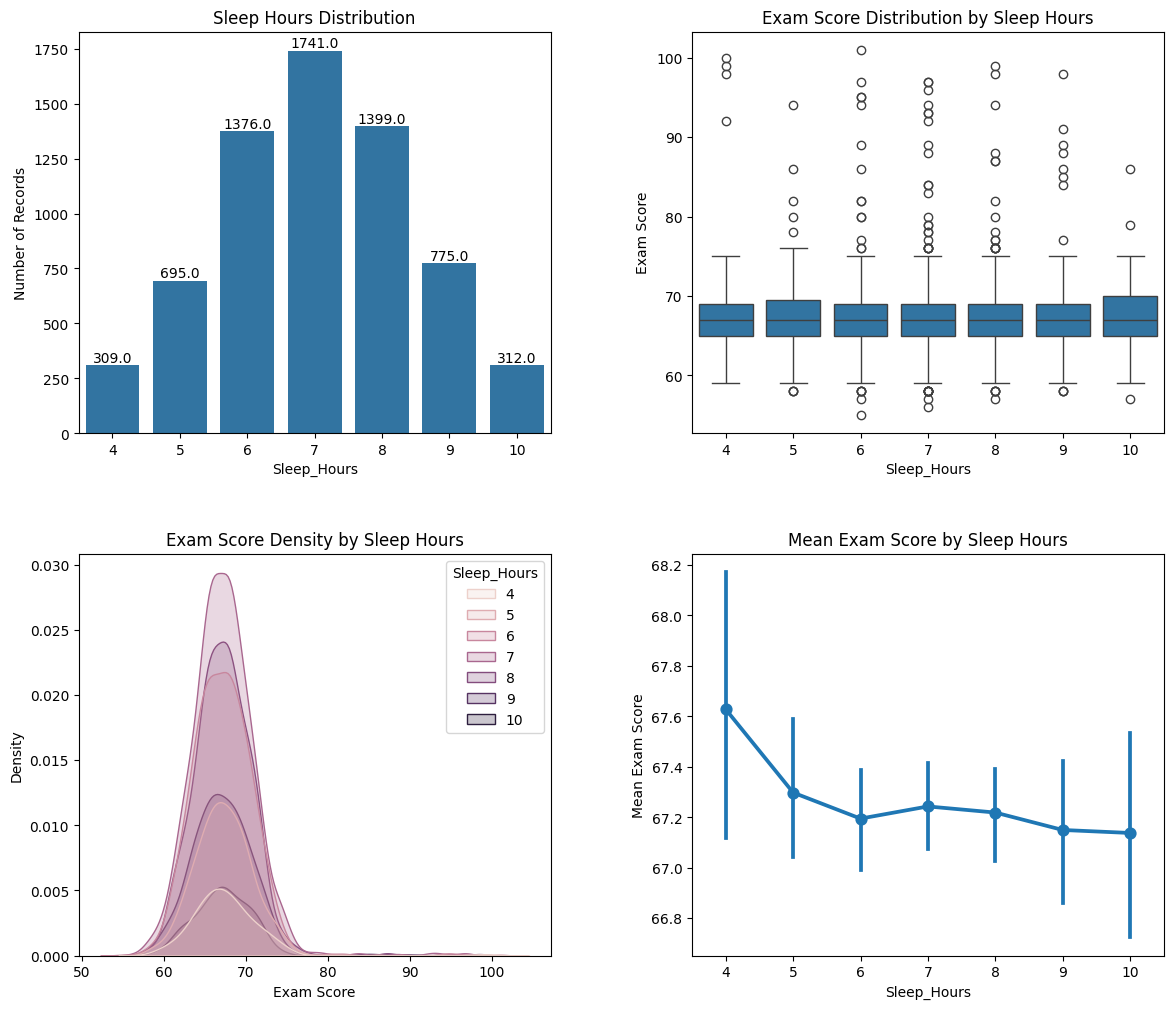

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Sleep_Hours", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Sleep Hours Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Sleep_Hours", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Sleep Hours")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Sleep_Hours", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Sleep Hours")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Sleep_Hours", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Sleep Hours")
ax[3].set_ylabel("Mean Exam Score") 


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The Sleep Hours feature is represented by seven discrete categories: 4, 5, 6, 7, 8, 9, and 10 hours. The distribution of observations across these categories is notably imbalanced, with counts ranging from 309 and 312 instances in the 4- and 10-hour categories, respectively, to a peak of 1,741 instances in the 7-hour category. This distribution approximates a normal shape, which may pose challenges for certain machine learning algorithms, particularly those sensitive to class imbalance.

An analysis of the mean exam scores and their distributions across the categories indicates a high degree of similarity. However, a more detailed examination reveals a slight negative relationship between sleep duration and mean exam score, suggesting that higher sleep durations are associated with marginally lower performance. This observation may appear counterintuitive and warrants further investigation.

**1.2.9 - Analysis of Previous Scores column**

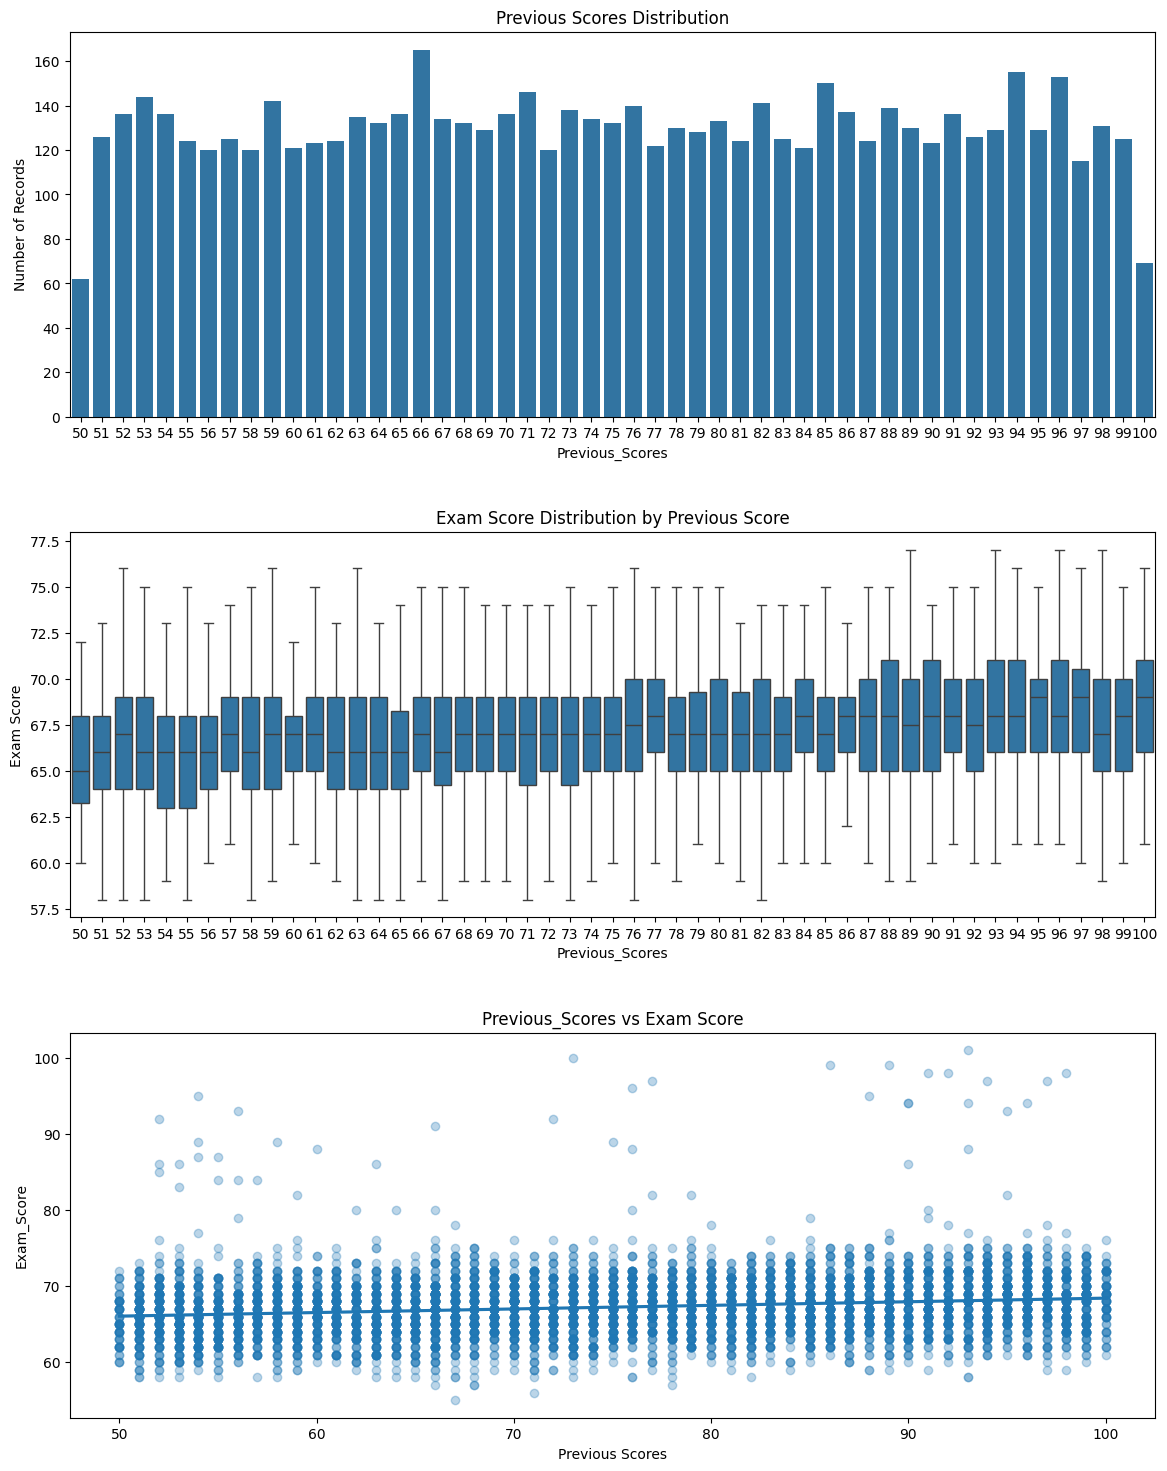

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(14, 18))
ax = ax.flatten()

sns.countplot(x="Previous_Scores", data=dataset, ax=ax[0])
ax[0].set_title("Previous Scores Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Previous_Scores", y="Exam_Score", data=dataset,
            ax=ax[1], showfliers=False)
ax[1].set_title("Exam Score Distribution by Previous Score")
ax[1].set_ylabel("Exam Score")

sns.regplot(
    x="Previous_Scores",
    y="Exam_Score",
    data=dataset,
    ax=ax[2],
    scatter_kws={"alpha": 0.3}
)
ax[2].set_title("Previous_Scores vs Exam Score")
ax[2].set_xlabel("Previous Scores")


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show() 

The Previous Scores feature ranges from 50 to 100. The distribution of values is relatively balanced across this range, with the exception of the boundary values (50 and 100), which have approximately half the number of observations compared to the other score levels.

This feature exhibits a slight positive correlation with the target variable (Exam Score), indicating that higher previous scores are modestly associated with improved exam performance.

**1.2.10 - Analysis of Motivational Level column**

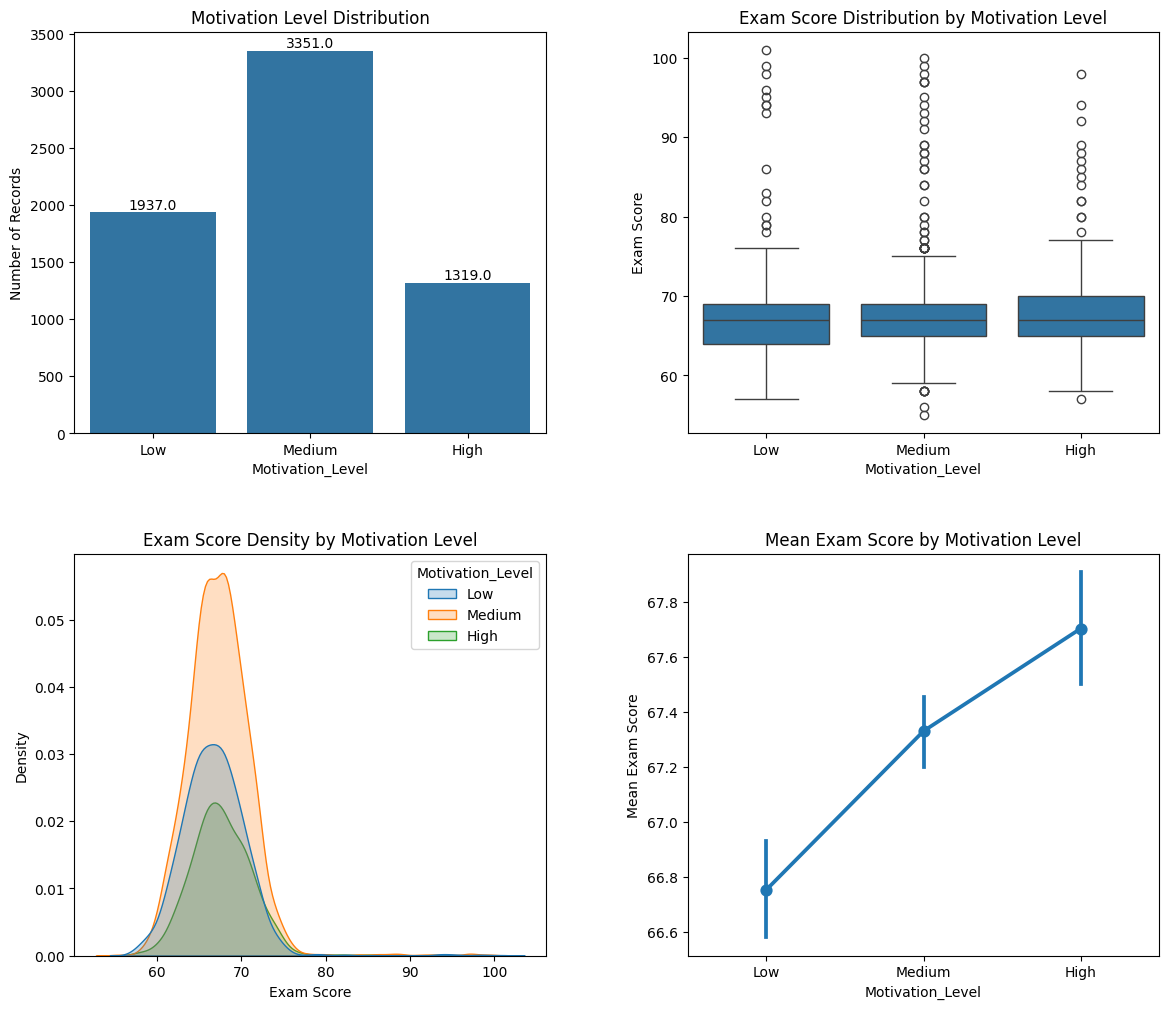

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Motivation_Level", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Motivation Level Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Motivation_Level", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Motivation Level")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Motivation_Level", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Motivation Level")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Motivation_Level", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Motivation Level")
ax[3].set_ylabel("Mean Exam Score") 


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The Motivation Level feature consists of three categories: low, medium, and high. Similar to previously discussed features, this variable is imbalanced, with the medium category containing the highest number of observations (3,351), followed by low (1,937) and high (1,319).

A comparison of the mean exam scores and their distributions across these categories indicates that higher levels of motivation are associated with better performance. Specifically, the high motivation category exhibits the highest average exam score. This suggests a positive correlation between motivation level and exam performance, indicating that this feature may be particularly informative for model training.

**1.2.11 - Analysis of Internet Access column**

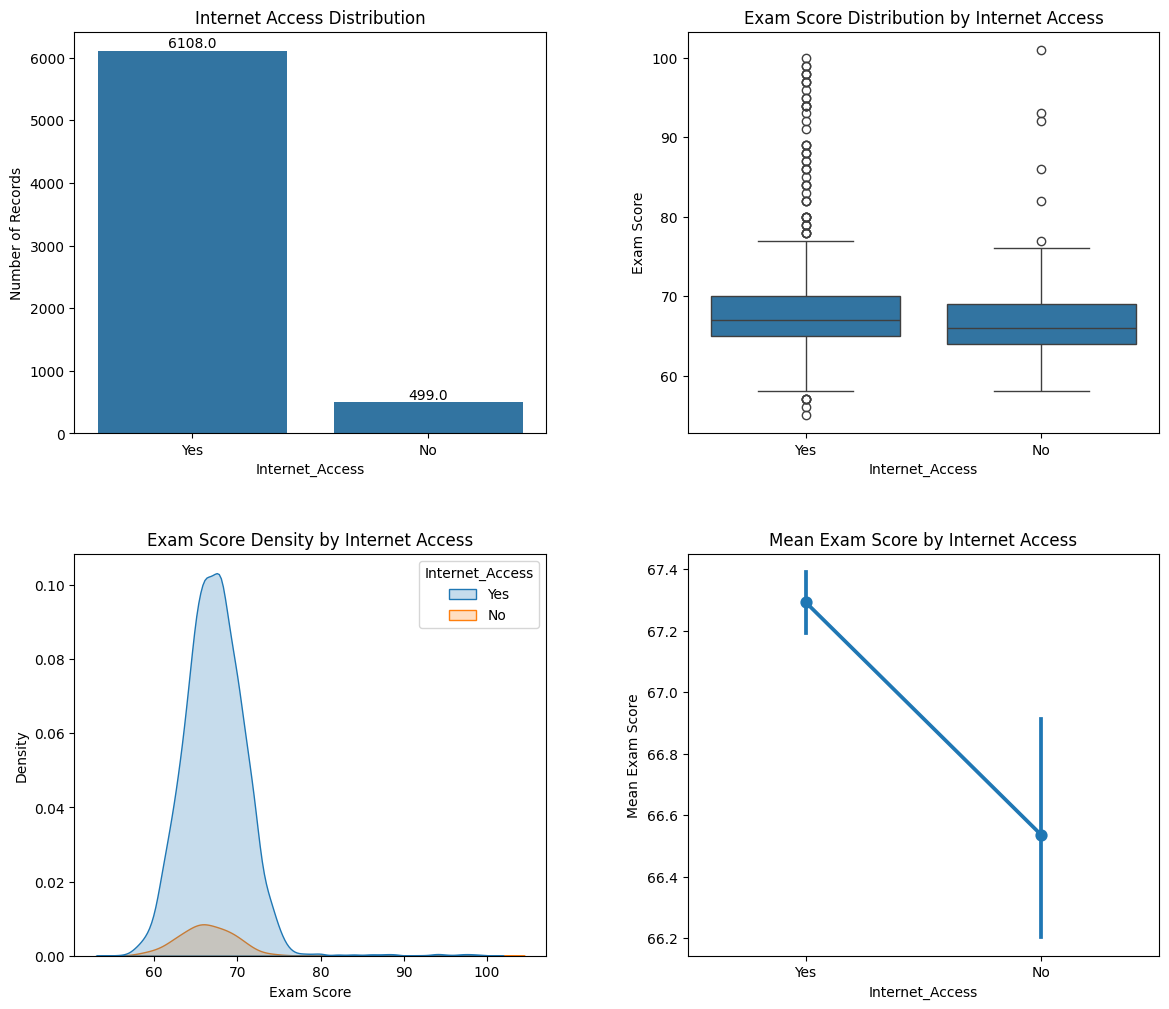

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Internet_Access", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Internet Access Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Internet_Access", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Internet Access")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Internet_Access", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Internet Access")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Internet_Access", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Internet Access")
ax[3].set_ylabel("Mean Exam Score") 


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The Internet Access feature is represented as a binary variable with two categories: yes and no. This feature is highly imbalanced, with the yes category containing approximately 12 times more observations than the no category (6,108 vs. 499). Such a pronounced imbalance may introduce challenges during model training and should therefore be carefully examined and, if necessary, appropriately addressed.

Despite this imbalance, an analysis of the distribution indicates a clear relationship between internet access and the target variable (Exam Score). This suggests that the feature may still provide valuable predictive information for the model.

**1.2.12 - Analysis of Tutoring Sessions column**

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Tutoring_Sessions", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Tutoring Sessions Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Tutoring_Sessions", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Tutoring Sessions")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Tutoring_Sessions", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Tutoring Sessions")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Tutoring_Sessions", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Tutoring Sessions")
ax[3].set_ylabel("Mean Exam Score") 


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The Tutoring Sessions feature consists of ten discrete categories, representing values from 0 to 9. This feature requires careful handling during preprocessing for two primary reasons. First, the distribution is highly imbalanced, with a scarcity of observations for categories representing six or more tutoring sessions. Second, the relationship between this feature and the target variable (Exam Score) is non-linear: the mean exam score increases from 0 to approximately 6 sessions, after which it begins to decline. This pattern may appear counterintuitive and suggests the presence of diminishing or adverse returns at higher levels of tutoring.

Despite these challenges, with appropriate preprocessing and feature engineering, this variable may provide valuable predictive insight and contribute positively to model performance, particularly when selecting algorithms capable of capturing non-linear relationships.

**1.2.13 - Analysis of Family Income column**

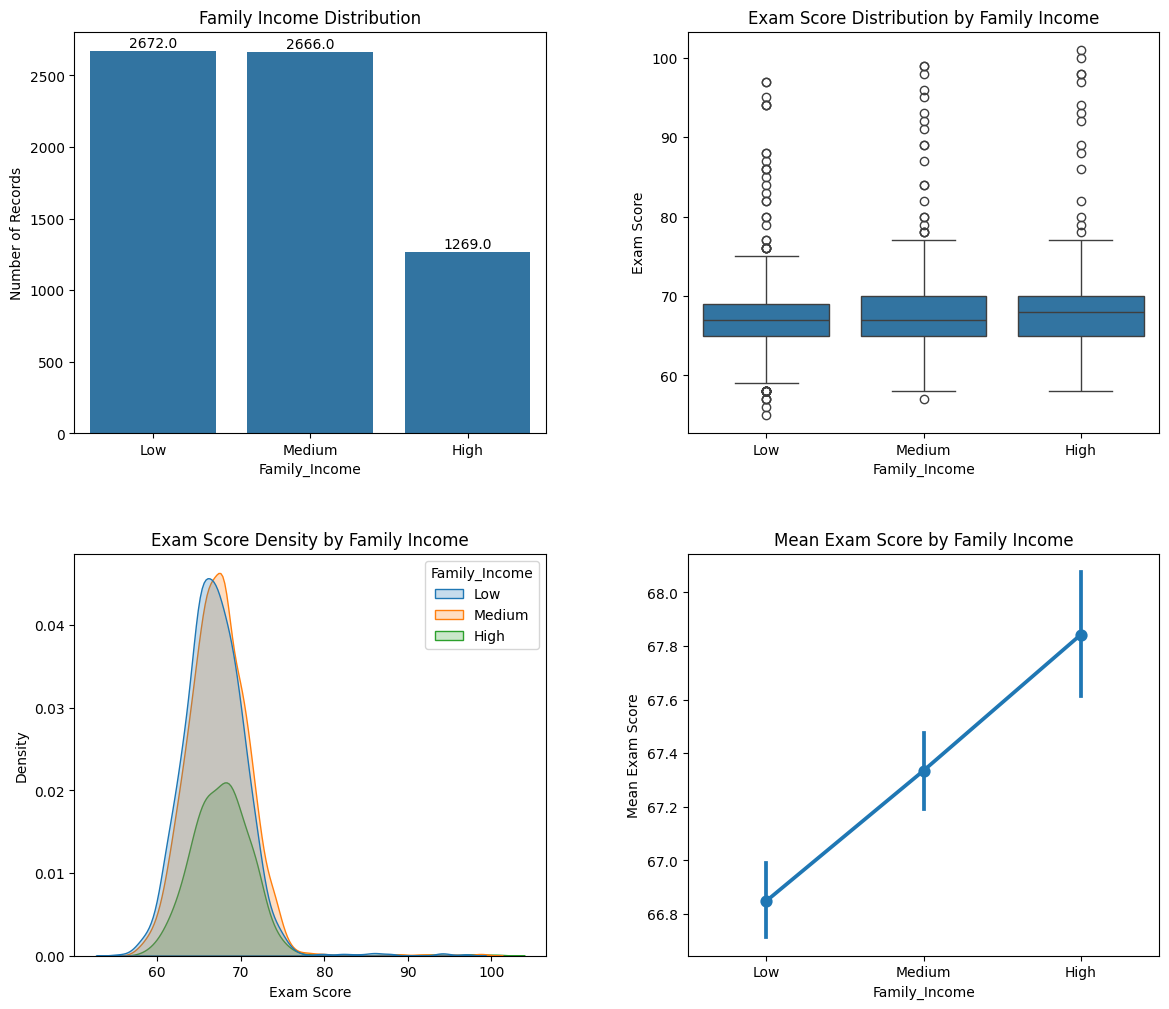

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Family_Income", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Family Income Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Family_Income", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Family Income")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Family_Income", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Family Income")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Family_Income", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Family Income")
ax[3].set_ylabel("Mean Exam Score") 


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The family income feature is divided into three categories: low, medium, and high. The distribution across these categories is imbalanced, with approximately 2,670 records each for the low and medium groups, and significantly fewer (1,269) in the high category.

An analysis of the distribution and the mean exam scores for each category shows a positive relationship between family income and exam performance. Students from higher-income families tend to have higher average exam scores. However, this correlation is relatively weak and affected by numerous outliers, which may negatively impact model performance.

Therefore, applying appropriate preprocessing techniques and feature engineering could help improve the model’s ability to learn from this feature.

**1.2.14 - Analysis of Teacher Quality column**

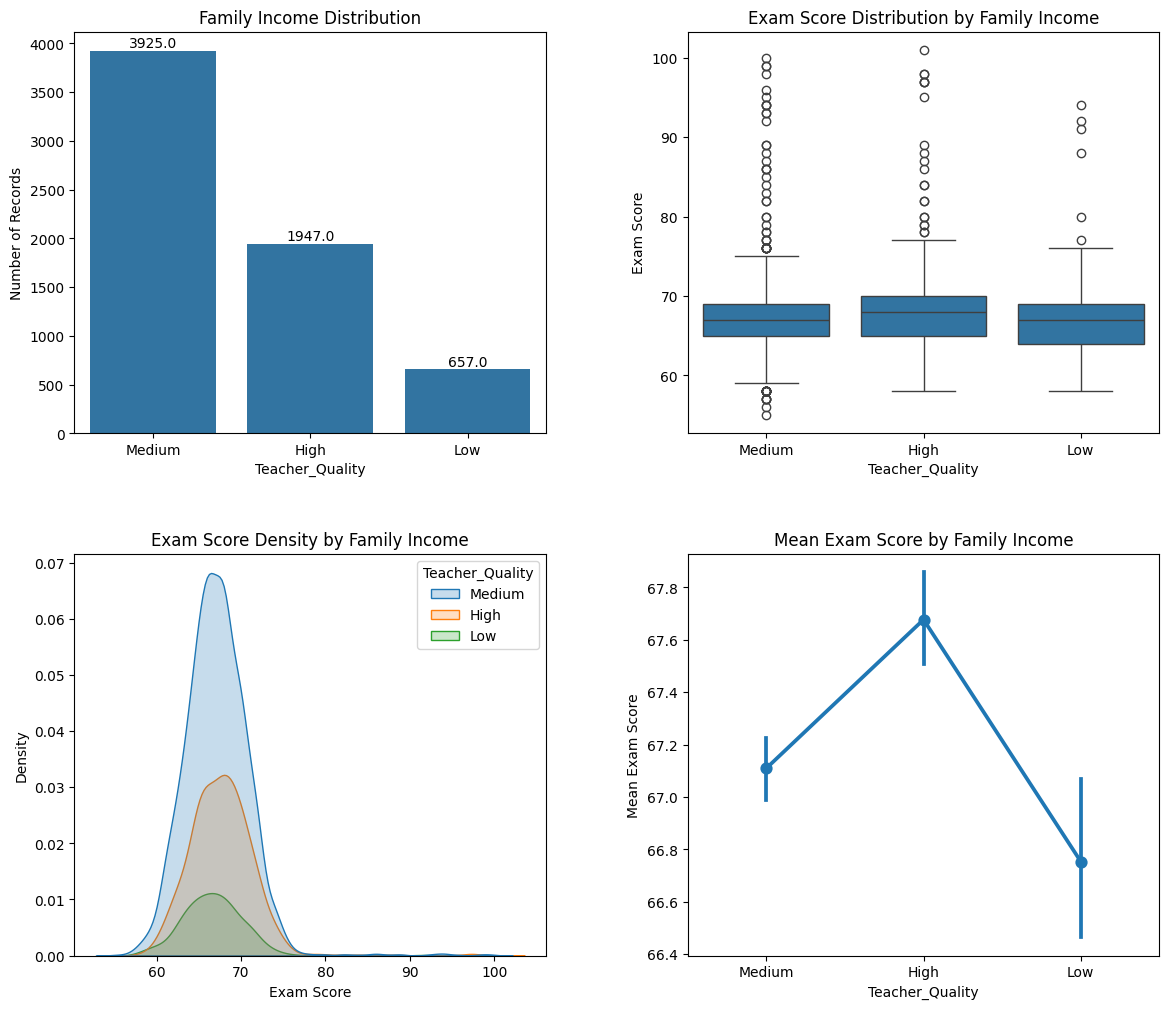

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

sns.countplot(x="Teacher_Quality", data=dataset, ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom")
ax[0].set_title("Teacher Quality Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Teacher_Quality", y="Exam_Score", data=dataset, ax=ax[1])
ax[1].set_title("Exam Score Distribution by Teacher Quality")
ax[1].set_ylabel("Exam Score")

sns.kdeplot(data=dataset, x="Exam_Score", hue="Teacher_Quality", fill=True, ax=ax[2])
ax[2].set_title("Exam Score Density by Teacher Quality")
ax[2].set_xlabel("Exam Score")

sns.pointplot(x="Teacher_Quality", y="Exam_Score", data=dataset, ax=ax[3])
ax[3].set_title("Mean Exam Score by Teacher Quality")
ax[3].set_ylabel("Mean Exam Score") 


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The teacher quality feature, like several previous features, is divided into three categories: low, medium, and high. This feature is also imbalanced, with the low category having the fewest records (657), followed by high (1,947), and medium containing the largest number of observations (3,925).

The distribution of this feature and the corresponding mean exam scores show a pattern similar to previously analyzed features. Higher teacher quality is associated with higher average exam scores. However, the differences between categories are minimal, indicating only a weak relationship between teacher quality and exam performance.